_IN6227 Assignment 1 — Variant 1: Comparing Two Classifiers_

Student: Xiong Weijie  
Matric number: G2609665B  
Course assignment: IN6227-Assignment-1

Install dependencies with `pip install numpy==2.2.6 pandas==2.3.3 scikit-learn==1.7.2 matplotlib==3.10.9`, then run top to bottom. Put the supplied `train.csv` and `test.csv` in `dataset/` or set `IN6227_DATA_DIR`. The data are not published in this repository.

_1. Goal and evaluation plan_

Compare logistic regression (linear) with random forest (nonlinear). Select by validation average precision (AP), which focuses on ranking the less common `yes` class; use the supplied `test.csv` only for the reported final comparison. The later five-fold check diagnoses split sensitivity without changing that selection. Because the expanded analysis followed an earlier test inspection, final test scores are descriptive.

In [1]:
import os
import hashlib
import sys
from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
    precision_recall_curve, roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 42
DATA_DIR = Path(os.environ.get("IN6227_DATA_DIR", "dataset"))
if not (DATA_DIR / "train.csv").exists() and (DATA_DIR / "dataset" / "train.csv").exists():
    DATA_DIR = DATA_DIR / "dataset"
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
assert train.columns.tolist() == test.columns.tolist(), "Train and test schemas differ"
assert "label" in train.columns
feature_columns = [c for c in train.columns if c != "label"]
numeric = train[feature_columns].select_dtypes(include="number").columns.tolist()
categorical = [c for c in feature_columns if c not in numeric]
print(f"Raw train/test rows: {len(train):,} / {len(test):,}")
print(f"Predictors: {len(feature_columns)} ({len(numeric)} numeric, {len(categorical)} categorical)")
print("Numeric:", numeric)
print("Categorical:", categorical)
print(f"Environment: Python {sys.version.split()[0]}, NumPy {np.__version__}, pandas {pd.__version__}, scikit-learn {sklearn.__version__}, Matplotlib {matplotlib.__version__}")
for source in ("train.csv", "test.csv"):
    digest = hashlib.sha256((DATA_DIR / source).read_bytes()).hexdigest()
    print(f"{source} SHA-256: {digest}")

Raw train/test rows: 31,112 / 13,334
Predictors: 15 (7 numeric, 8 categorical)
Numeric: ['aptitude_score', 'performance_score', 'stability_index', 'load_ratio', 'index_weight', 'activity_duration', 'composite_rank']
Categorical: ['geological_era', 'weather_pattern', 'region', 'personal_interest', 'brew_preference', 'instrument', 'species', 'mineral_type']
Environment: Python 3.10.8, NumPy 2.2.6, pandas 2.3.3, scikit-learn 1.7.2, Matplotlib 3.10.9
train.csv SHA-256: 5211257faf4212e248fb5661b3bfa1a639bfb4c54a646619c4d906a3e1cfa0a2
test.csv SHA-256: eee9de74f74357ad72848b36e8c34f09ad60ea2b60ea7ebd346be987f4909ac8


_2. Data inspection and cleaning decisions_

The supplied files have 15 predictors. Drop only the 3 training and 1 test rows without labels; impute missing predictors inside each training fold. No exact duplicates were found. Long-tailed values and rare categories remain because their validity cannot be judged from the supplied feature names.

In [2]:
train_clean = train.dropna(subset=["label"]).copy()
test_clean = test.dropna(subset=["label"]).copy()
assert set(train_clean["label"]) == {"no", "yes"}
assert set(test_clean["label"]) == {"no", "yes"}

summary = pd.DataFrame({
    "train": [len(train), len(train_clean), int(train[feature_columns].isna().sum().sum()),
              int(train.duplicated().sum()), float((train_clean["label"] == "yes").mean())],
    "test": [len(test), len(test_clean), int(test[feature_columns].isna().sum().sum()),
             int(test.duplicated().sum()), float((test_clean["label"] == "yes").mean())],
}, index=["raw rows", "labeled rows", "missing predictor cells", "exact duplicate rows", "yes prevalence"])
display(summary)
display(train[feature_columns].isna().sum().loc[lambda s: s > 0].to_frame("missing train cells"))
display(train[numeric].describe(percentiles=[0.25, 0.5, 0.75]).T[["min", "25%", "50%", "75%", "max"]])

,train,test
raw rows,31112.000000,13334.000000
labeled rows,31109.000000,13333.000000
missing predictor cells,47.000000,20.000000
exact duplicate rows,0.000000,0.000000
yes prevalence,0.239931,0.237606


,missing train cells
geological_era,2
weather_pattern,3
region,4
aptitude_score,4
performance_score,2
stability_index,2
personal_interest,6
load_ratio,2
brew_preference,7
instrument,3


,min,25%,50%,75%,max
aptitude_score,90.000,310.5975,333.515,402.56250,510.000
performance_score,0.000,146.5725,275.385,420.17000,1010.000
stability_index,0.000,2.7510,3.351,3.76175,4.625
load_ratio,0.000,19.2720,23.689,27.65675,143.717
index_weight,0.000,7.5200,11.730,16.23000,99.620
activity_duration,0.000,72.7400,80.330,90.25750,205.000
composite_rank,0.589,2.5910,3.199,3.83800,6.876


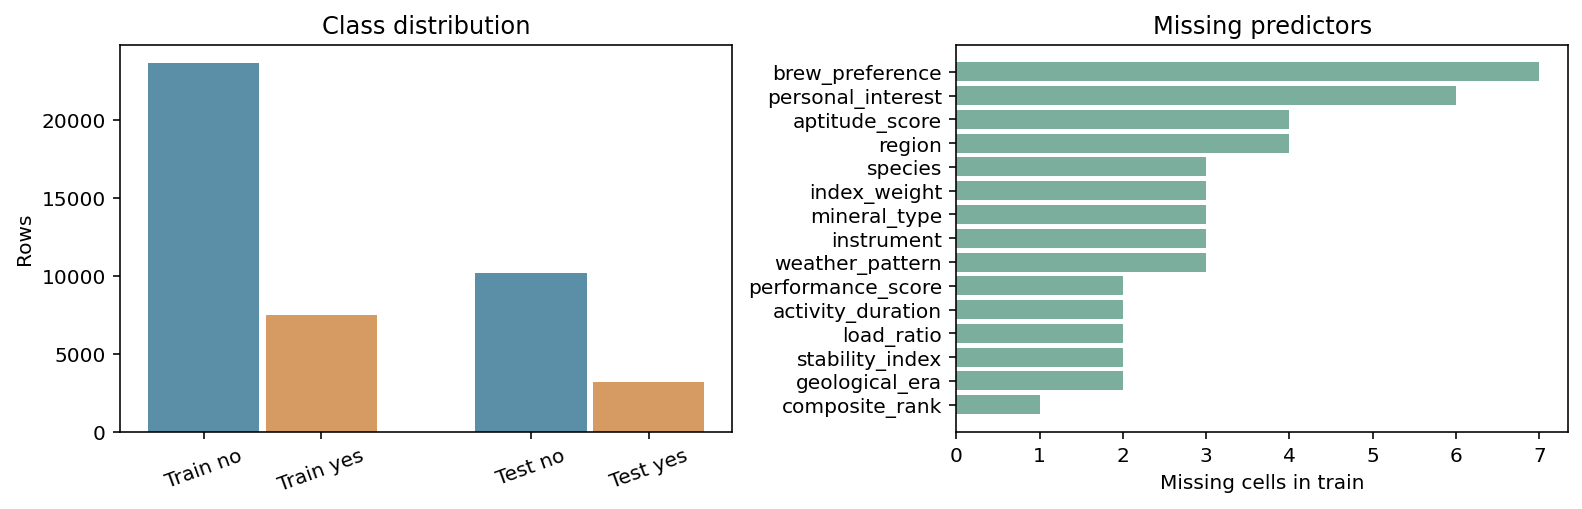

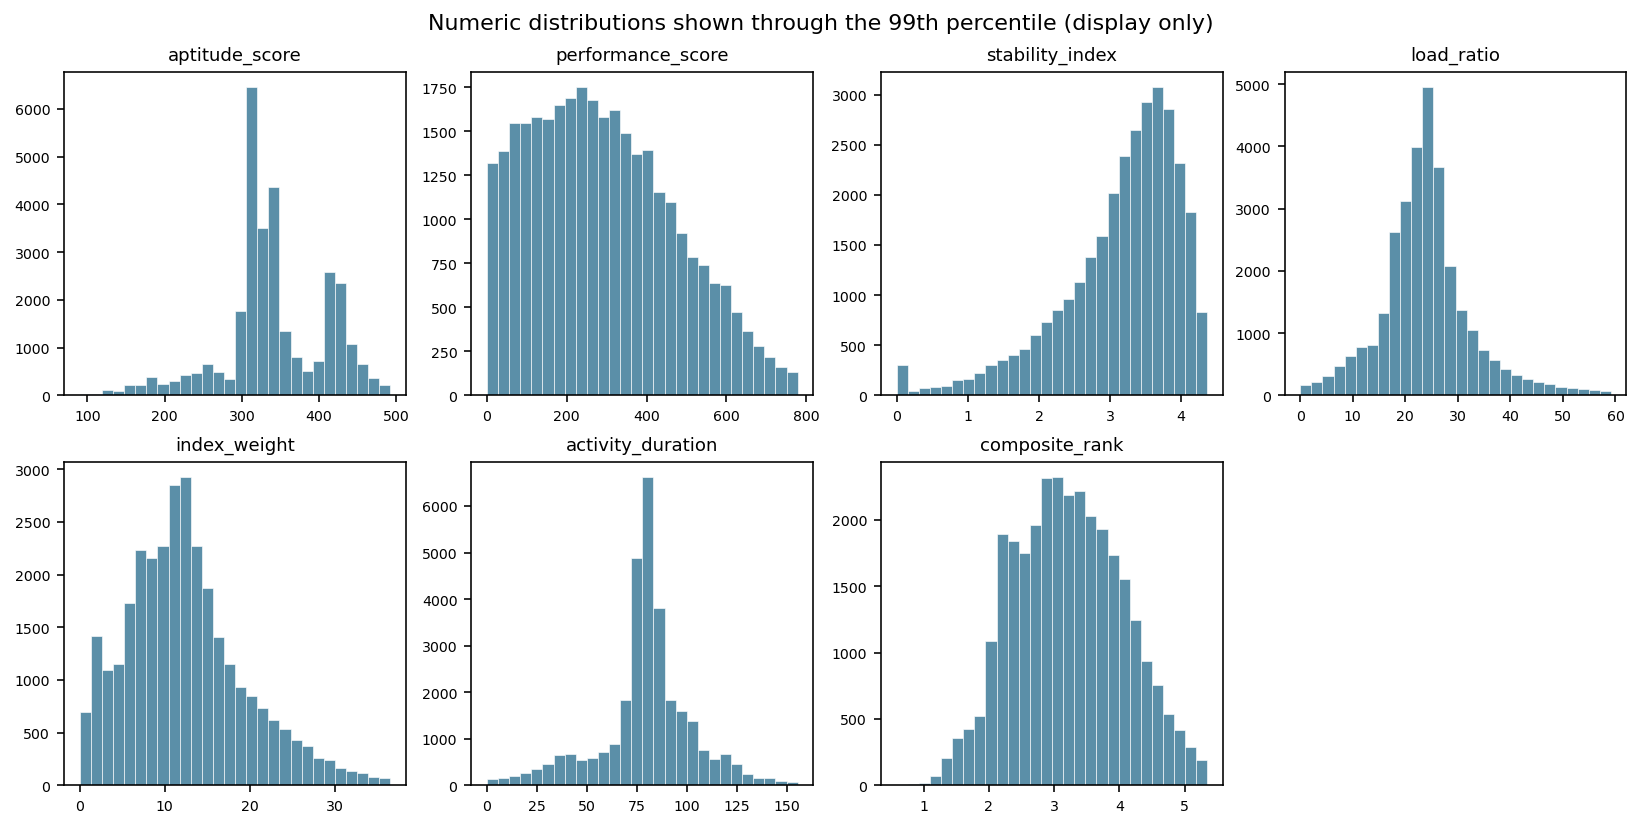

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 3.4), layout="constrained")
for position, (name, frame) in enumerate((("Train", train_clean), ("Test", test_clean))):
    counts = frame["label"].value_counts().reindex(["no", "yes"], fill_value=0)
    axes[0].bar([position - 0.18, position + 0.18], counts,
                width=0.34, color=["#5b8fa8", "#d59b63"])
axes[0].set_xticks([-0.18, 0.18, 0.82, 1.18], ["Train no", "Train yes", "Test no", "Test yes"], rotation=20)
axes[0].set_ylabel("Rows")
axes[0].set_title("Class distribution")
missing_by_feature = train[feature_columns].isna().sum()
missing_by_feature = missing_by_feature[missing_by_feature > 0].sort_values()
axes[1].barh(missing_by_feature.index, missing_by_feature.values, color="#7cae9e")
axes[1].set_xlabel("Missing cells in train")
axes[1].set_title("Missing predictors")
display(fig)
plt.close(fig)

fig, axes = plt.subplots(2, 4, figsize=(11.2, 5.6), layout="constrained")
for ax, column in zip(axes.flat, numeric):
    values = train_clean[column].dropna()
    upper = values.quantile(0.99)
    ax.hist(values[values <= upper], bins=28, color="#5b8fa8", edgecolor="white", linewidth=0.3)
    ax.set_title(column, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in list(axes.flat)[len(numeric):]:
    ax.axis("off")
fig.suptitle("Numeric distributions shown through the 99th percentile (display only)", fontsize=11)
display(fig)
plt.close(fig)

_3. Features, split and leakage-safe preprocessing_

Keep all predictors. In each pipeline, median-impute and standardize numeric columns; mode-impute and one-hot encode categories, ignoring unseen levels. Fitting these steps only on training folds prevents leakage. Use a stratified 80/20 development split with seed 42.

In [4]:
# pandas nullable string columns are converted to object so sklearn receives np.nan.
for frame in (train_clean, test_clean):
    frame[categorical] = frame[categorical].astype(object)
    frame[categorical] = frame[categorical].where(pd.notna(frame[categorical]), np.nan)

X = train_clean[feature_columns]
y = (train_clean["label"] == "yes").astype(int)
X_test = test_clean[feature_columns]
y_test = (test_clean["label"] == "yes").astype(int)
X_fit, X_val, y_fit, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

def preprocessing():
    return ColumnTransformer([
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), numeric),
        ("categorical", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), categorical),
    ])

print(f"Development fit/validation rows: {len(X_fit):,} / {len(X_val):,}")
print(f"Positive prevalence: fit={y_fit.mean():.3%}, validation={y_val.mean():.3%}")

Development fit/validation rows: 24,887 / 6,222
Positive prevalence: fit=23.992%, validation=23.995%


_4. Model configuration and recorded parameter search_

Compare 12 preset configurations on the same validation split: logistic `C` (0.1/1/10) and class weighting; forest depth (12/unlimited) and minimum leaf size (2/5/10), with 150 trees. Logistic `lbfgs` stops at convergence or 1,000 iterations; forest trees stop at their split constraints. Select each family's highest validation AP, without using test labels.

In [5]:
def summarize(y_true, probability):
    predicted = probability >= 0.5
    return {
        "accuracy": accuracy_score(y_true, predicted),
        "balanced_accuracy": balanced_accuracy_score(y_true, predicted),
        "precision_yes": precision_score(y_true, predicted, zero_division=0),
        "recall_yes": recall_score(y_true, predicted, zero_division=0),
        "f1_yes": f1_score(y_true, predicted, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probability),
        "average_precision": average_precision_score(y_true, probability),
        "confusion_matrix_no_yes": confusion_matrix(y_true, predicted).tolist(),
    }

candidates = {}
for weight in (None, "balanced"):
    for c in (0.1, 1, 10):
        candidates[f"logistic_C_{c:g}_weight_{weight or 'none'}"] = LogisticRegression(
            C=c, class_weight=weight, max_iter=1000, solver="lbfgs", random_state=SEED
        )
for depth in (12, None):
    for leaf in (2, 5, 10):
        candidates[f"forest_depth_{depth or 'none'}_leaf_{leaf}"] = RandomForestClassifier(
            n_estimators=150, max_depth=depth, min_samples_leaf=leaf, n_jobs=-1, random_state=SEED
        )
validation = {}
for name, classifier in candidates.items():
    pipe = Pipeline([("prep", preprocessing()), ("classifier", classifier)])
    pipe.fit(X_fit, y_fit)
    validation[name] = summarize(y_val, pipe.predict_proba(X_val)[:, 1])
    if name.startswith("logistic"):
        validation[name]["iterations"] = int(pipe.named_steps["classifier"].n_iter_[0])

validation_table = pd.DataFrame(validation).T.drop(columns="confusion_matrix_no_yes")
display(validation_table[["average_precision", "roc_auc", "recall_yes", "iterations"]].round(5))
selections = {
    family: max((name for name in candidates if name.startswith(prefix)),
                key=lambda name: validation[name]["average_precision"])
    for family, prefix in [("logistic_regression", "logistic"),
                           ("random_forest", "forest")]
}
print("Selected by validation AP:", selections)

,average_precision,roc_auc,recall_yes,iterations
logistic_C_0.1_weight_none,0.696288,0.885553,0.551239,75
logistic_C_1_weight_none,0.697381,0.886337,0.559946,87
logistic_C_10_weight_none,0.697749,0.88652,0.561956,145
logistic_C_0.1_weight_balanced,0.692895,0.884936,0.851306,77
logistic_C_1_weight_balanced,0.694289,0.885609,0.851306,95
logistic_C_10_weight_balanced,0.69451,0.885781,0.853985,124
forest_depth_12_leaf_2,0.696411,0.883728,0.496986,NaN
forest_depth_12_leaf_5,0.693075,0.88396,0.496316,NaN
forest_depth_12_leaf_10,0.693138,0.883618,0.488948,NaN
forest_depth_none_leaf_2,0.690368,0.883446,0.539853,NaN


Selected by validation AP: {'logistic_regression': 'logistic_C_10_weight_none', 'random_forest': 'forest_depth_none_leaf_5'}


The split selects unweighted logistic `C=10` (AP 0.69775; 145 iterations) and unlimited-depth forest with leaf size 5 (AP 0.69663). Balanced weights raise recall at 0.50 but reduce AP. Differences between nearby settings are small.

_Five-fold sensitivity check of the same 12 settings_

Repeat the same 12 settings across five training-only folds. Each fold refits preprocessing and the model. Fold mean and standard deviation of AP show split sensitivity; this later check is not an independent test or a reason to change the original selection.

In [6]:
cv_rows = []
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for name, classifier in candidates.items():
    for fold, (fit_index, val_index) in enumerate(folds.split(X, y), start=1):
        pipe = Pipeline([("prep", preprocessing()), ("classifier", classifier)])
        pipe.fit(X.iloc[fit_index], y.iloc[fit_index])
        truth = y.iloc[val_index]
        probability = pipe.predict_proba(X.iloc[val_index])[:, 1]
        cv_rows.append({
            "candidate": name, "fold": fold,
            "average_precision": average_precision_score(truth, probability),
            "roc_auc": roc_auc_score(truth, probability),
            "recall_at_0_5": recall_score(truth, probability >= 0.5),
        })
cv_folds = pd.DataFrame(cv_rows)
cv_summary = cv_folds.groupby("candidate").agg(
    cv_ap_mean=("average_precision", "mean"),
    cv_ap_sd=("average_precision", "std"),
    cv_roc_auc_mean=("roc_auc", "mean"),
    cv_recall_mean=("recall_at_0_5", "mean"),
).sort_values("cv_ap_mean", ascending=False)
display(cv_summary.round(5))

,cv_ap_mean,cv_ap_sd,cv_roc_auc_mean,cv_recall_mean
candidate,,,,
forest_depth_none_leaf_10,0.71467,0.01850,0.89095,0.54515
forest_depth_12_leaf_2,0.71411,0.01860,0.89020,0.51461
forest_depth_12_leaf_5,0.71371,0.01829,0.89023,0.50764
forest_depth_none_leaf_5,0.71359,0.01891,0.89051,0.55507
forest_depth_12_leaf_10,0.71303,0.01836,0.89011,0.50657
logistic_C_10_weight_none,0.70929,0.01540,0.89062,0.56431
logistic_C_1_weight_none,0.70904,0.01545,0.89066,0.56243
forest_depth_none_leaf_2,0.70838,0.01684,0.88839,0.56284
logistic_C_0.1_weight_none,0.70799,0.01545,0.89046,0.55681


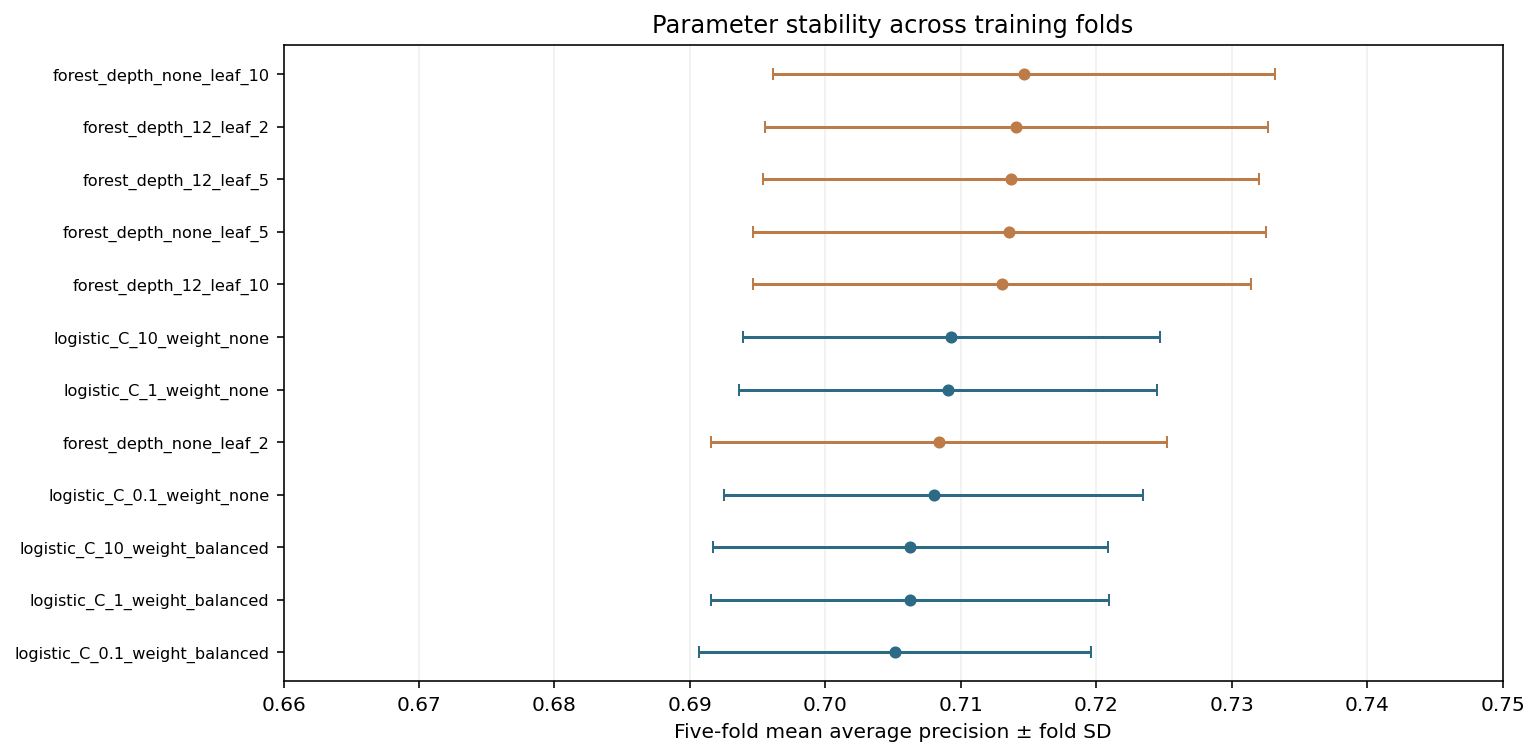

In [7]:
cv_plot = cv_summary.sort_values("cv_ap_mean")
fig, ax = plt.subplots(figsize=(10.5, 5.1), layout="constrained")
for position, (name, row) in enumerate(cv_plot.iterrows()):
    color = "#2d6a85" if name.startswith("logistic") else "#bd7b47"
    ax.errorbar(row["cv_ap_mean"], position, xerr=row["cv_ap_sd"],
                fmt="o", color=color, capsize=3, markersize=5)
ax.set_yticks(range(len(cv_plot)), cv_plot.index, fontsize=8)
ax.set_xlim(0.66, 0.75)
ax.set_xlabel("Five-fold mean average precision ± fold SD")
ax.set_title("Parameter stability across training folds")
ax.grid(axis="x", alpha=0.2)
display(fig)
plt.close(fig)

Selected logistic/forest settings average AP 0.70929/0.71359. Forest leaf size 10 averages 0.71467, just 0.00108 above leaf size 5; the one-split optimum is fragile. Error bars show fold SD, not confidence intervals.

_Feature-availability sensitivity: `composite_rank`_

`composite_rank` may be derived and unavailable at prediction time. Drop it on the same validation split to check whether either selected model depends strongly on it; do not use this check to retune test results.

In [8]:
without_rank = [c for c in feature_columns if c != "composite_rank"]
numeric_without = [c for c in numeric if c != "composite_rank"]
categorical_without = [c for c in categorical if c != "composite_rank"]
preprocessor_without_rank = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_without),
    ("categorical", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_without),
])
sensitivity_rows = []
for family, selected_name in selections.items():
    pipe = Pipeline([("prep", preprocessor_without_rank),
                     ("classifier", candidates[selected_name])])
    pipe.fit(X_fit[without_rank], y_fit)
    probability = pipe.predict_proba(X_val[without_rank])[:, 1]
    sensitivity_rows.append({
        "model": family,
        "AP all 15": validation[selected_name]["average_precision"],
        "AP without composite_rank": average_precision_score(y_val, probability),
    })
sensitivity_table = pd.DataFrame(sensitivity_rows).set_index("model")
sensitivity_table["AP change"] = (sensitivity_table["AP without composite_rank"]
                                  - sensitivity_table["AP all 15"])
display(sensitivity_table.round(5))

,AP all 15,AP without composite_rank,AP change
model,,,
logistic_regression,0.69775,0.69769,-0.00006
random_forest,0.69663,0.69618,-0.00044


Removing `composite_rank` changes validation AP by less than 0.0005 for either model. Feature availability still needs external verification.

_Validation-only threshold trade-off_

Inspect four illustrative thresholds on the original validation split. A lower threshold may catch more `yes` cases but trigger more false positives. The reported test comparison remains fixed at 0.50 because no error-cost target was supplied.

In [9]:
threshold_rows = []
for family, selected_name in selections.items():
    pipe = Pipeline([("prep", preprocessing()),
                     ("classifier", candidates[selected_name])])
    pipe.fit(X_fit, y_fit)
    probability = pipe.predict_proba(X_val)[:, 1]
    for threshold in (0.30, 0.40, 0.50, 0.60):
        predicted = probability >= threshold
        tn, fp, fn, tp = confusion_matrix(y_val, predicted).ravel()
        threshold_rows.append({
            "model": family, "threshold": threshold,
            "precision_yes": precision_score(y_val, predicted, zero_division=0),
            "recall_yes": recall_score(y_val, predicted, zero_division=0),
            "f1_yes": f1_score(y_val, predicted, zero_division=0),
            "false_positives": int(fp), "false_negatives": int(fn),
        })
threshold_table = pd.DataFrame(threshold_rows).set_index(["model", "threshold"])
display(threshold_table.round(4))

precision_yes  recall_yes  f1_yes  false_positives  false_negatives
model               threshold                                                                     
logistic_regression 0.3               0.5703      0.7930  0.6635              892              309
                    0.4               0.6323      0.6772  0.6539              588              482
                    0.5               0.6843      0.5620  0.6171              387              654
                    0.6               0.7483      0.4461  0.5590              224              827
random_forest       0.3               0.5651      0.7964  0.6611              915              304
                    0.4               0.6272      0.6772  0.6512              601              482
                    0.5               0.6852      0.5291  0.5971              363              703
                    0.6               0.7433      0.4113  0.5295              212              879

On validation, logistic recall rises from 0.562 to 0.793 at thresholds 0.50→0.30, while false positives rise from 387 to 892. This illustrates a trade-off, not a deployment recommendation.

_5. Refit and evaluate the supplied test file_

Refit the fixed settings on all labeled training rows, then score the supplied test file once at 0.50. AP and ROC-AUC use probabilities; confusion matrices use the threshold. Always predicting `no` gets 76.2% accuracy but zero `yes` recall. These test scores remain descriptive after the earlier test inspection.

In [10]:
held_out = {}
test_probabilities = {}
for family, selected_name in selections.items():
    pipe = Pipeline([("prep", preprocessing()),
                     ("classifier", candidates[selected_name])])
    pipe.fit(X, y)
    probability = pipe.predict_proba(X_test)[:, 1]
    test_probabilities[family] = probability
    held_out[family] = summarize(y_test, probability)

test_table = pd.DataFrame(held_out).T.drop(columns="confusion_matrix_no_yes")
display(test_table.round(4))
print(f"Always-no accuracy: {(y_test == 0).mean():.4f}; yes recall: 0")
for family, result in held_out.items():
    print(f"{family} confusion matrix (true rows / predicted columns: no, yes):")
    display(pd.DataFrame(result["confusion_matrix_no_yes"],
                         index=["true no", "true yes"],
                         columns=["pred no", "pred yes"]))

,accuracy,balanced_accuracy,precision_yes,recall_yes,f1_yes,roc_auc,average_precision
logistic_regression,0.839571,0.747253,0.698572,0.571338,0.628581,0.888825,0.702472
random_forest,0.839271,0.745101,0.700274,0.565657,0.625808,0.889711,0.708431


Always-no accuracy: 0.7624; yes recall: 0
logistic_regression confusion matrix (true rows / predicted columns: no, yes):


,pred no,pred yes
true no,9384,781
true yes,1358,1810


random_forest confusion matrix (true rows / predicted columns: no, yes):


,pred no,pred yes
true no,9398,767
true yes,1376,1792


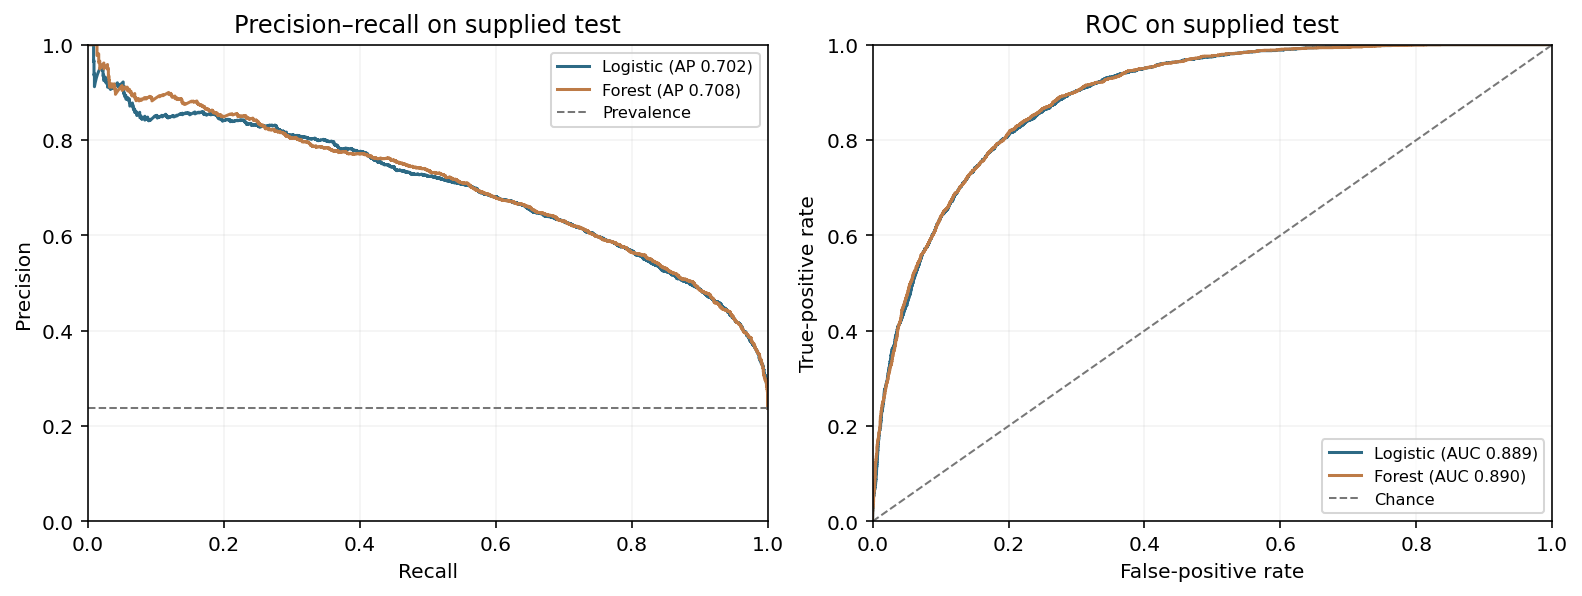

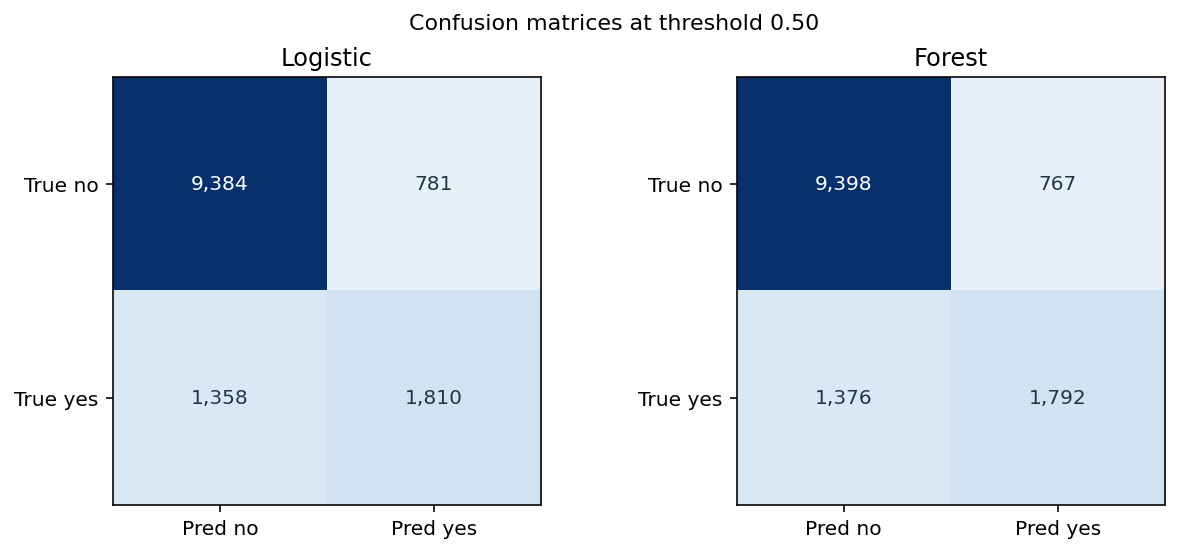

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.0), layout="constrained")
for family, probability in test_probabilities.items():
    label = "Logistic" if family == "logistic_regression" else "Forest"
    color = "#2d6a85" if family == "logistic_regression" else "#bd7b47"
    precision, recall, _ = precision_recall_curve(y_test, probability)
    fpr, tpr, _ = roc_curve(y_test, probability)
    axes[0].plot(recall, precision, label=f"{label} (AP {held_out[family]['average_precision']:.3f})", color=color)
    axes[1].plot(fpr, tpr, label=f"{label} (AUC {held_out[family]['roc_auc']:.3f})", color=color)
axes[0].axhline(y_test.mean(), color="#777777", linestyle="--", linewidth=1, label="Prevalence")
axes[1].plot([0, 1], [0, 1], color="#777777", linestyle="--", linewidth=1, label="Chance")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision–recall on supplied test")
axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC on supplied test")
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc="best", fontsize=8)
    ax.grid(alpha=0.15)
display(fig)
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.7), layout="constrained")
maximum = max(np.max(held_out[family]["confusion_matrix_no_yes"]) for family in held_out)
for ax, (family, result) in zip(axes, held_out.items()):
    matrix = np.asarray(result["confusion_matrix_no_yes"])
    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=maximum)
    ax.set_xticks([0, 1], ["Pred no", "Pred yes"])
    ax.set_yticks([0, 1], ["True no", "True yes"])
    ax.set_title("Logistic" if family == "logistic_regression" else "Forest")
    for row in range(2):
        for column in range(2):
            ax.text(column, row, f"{matrix[row, column]:,}", ha="center", va="center",
                    color="white" if matrix[row, column] > maximum / 2 else "#203647", fontsize=10)
fig.suptitle("Confusion matrices at threshold 0.50", fontsize=11)
display(fig)
plt.close(fig)

Both models reach about 84% accuracy. Logistic recall is 0.571 versus forest 0.566 at 0.50; forest AP is 0.708 versus logistic 0.702. The curves show ranking across thresholds, while the matrices show that each model misses over 1,350 positive cases at 0.50.

_6. Uncertainty in the AP difference_

Estimate uncertainty in the forest-minus-logistic AP gap with 1,000 paired resamples of test rows. The same sampled rows are used for both fixed models. This interval describes this dataset; it excludes model-selection uncertainty.

In [12]:
rng = np.random.default_rng(SEED)
y_array = y_test.to_numpy()
paired_differences = []
for _ in range(1000):
    sample = rng.integers(0, len(y_array), len(y_array))
    if len(np.unique(y_array[sample])) < 2:
        continue
    paired_differences.append(
        average_precision_score(y_array[sample], test_probabilities["random_forest"][sample])
        - average_precision_score(y_array[sample], test_probabilities["logistic_regression"][sample])
    )
interval = np.quantile(paired_differences, [0.025, 0.975])
gap = held_out["random_forest"]["average_precision"] - held_out["logistic_regression"]["average_precision"]
print(f"Forest - logistic test AP: {gap:.4f}")
print(f"Paired bootstrap 95% interval: [{interval[0]:.4f}, {interval[1]:.4f}]")

Forest - logistic test AP: 0.0060
Paired bootstrap 95% interval: [-0.0015, 0.0132]


The AP-difference interval is about [-0.0015, 0.0132]. Since it includes zero, these results do not establish a clear winner.

_7. Discussion, limitations and decision_

1. Start with logistic regression when simplicity and 0.50-threshold recall matter; consider forest when ranking by AP matters. Neither has a decisive advantage here.
2. The forest's preferred leaf size changes across validation designs, and test labels were viewed before the expanded analysis. A fresh external test is needed for independent confirmation.
3. Choose any operational threshold from explicit error costs and verify when predictors are available; `composite_rank` provenance is unknown.